In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

#gros_pd = pd.DataFrame()
#for nb_features in range(1,55):
#    df = pd.read_csv(f'../data/nested_CV_checker_{nb_features}_ft.csv', index_col = 0)
#    df['nb_features'] = nb_features
#    gros_pd = pd.concat([gros_pd,df.reset_index()])
#

<Axes: xlabel='n_features', ylabel='pearson_r'>

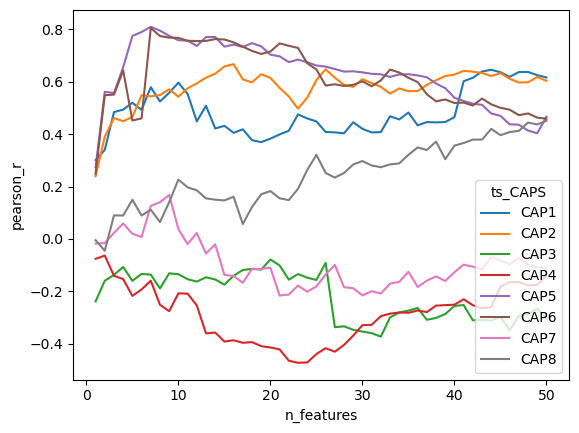

In [7]:
df = pd.read_csv("/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/subject_level_feature_selection/sub-01_task-rest_desc-CustomEnvBk8CapsEegOnly_predictions.csv")
sns.lineplot(
    data=df,
    x = "n_features",
    y = "pearson_r",
    hue= 'ts_CAPS',
    errorbar=None,
)

,subject,session,ts_CAPS,pearson_r,frequency_Hz,electrode,n_features,task,description
0,1,1,CAP1,0.301184,[0],[60],1,rest,CustomEnvBk8Caps
1,1,1,CAP2,0.239527,[0],[60],1,rest,CustomEnvBk8Caps
2,1,1,CAP3,-0.238593,[14],[30],1,rest,CustomEnvBk8Caps
3,1,1,CAP4,-0.075933,[14],[18],1,rest,CustomEnvBk8Caps
4,1,1,CAP5,0.273634,[21],[29],1,rest,CustomEnvBk8Caps
...,...,...,...,...,...,...,...,...,...
395,1,1,CAP4,-0.139996,[14 15 13 12 14 15 7 14 7 7 12 13 16 12 13 ...,[18 18 18 18 30 43 31 43 20 16 36 36 18 35 30 ...,50,rest,CustomEnvBk8Caps
396,1,1,CAP5,0.466922,[21 22 21 21 11 13 20 13 20 12 22 23 18 22 19 ...,[29 15 56 15 13 13 29 27 56 13 29 15 10 50 10 ...,50,rest,CustomEnvBk8Caps
397,1,1,CAP6,0.459142,[21 22 21 21 20 20 13 23 11 22 21 22 20 22 13 ...,[29 15 56 15 56 29 13 15 13 50 50 29 15 56 27 ...,50,rest,CustomEnvBk8Caps
398,1,1,CAP7,-0.109518,[19 20 30 31 19 32 27 21 16 21 26 20 20 21 29 ...,[47 47 47 47 53 47 6 24 51 47 6 24 53 29 47 ...,50,rest,CustomEnvBk8Caps


In [5]:
from pathlib import Path
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
directory = Path("/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/subject_level_feature_selection")
TASK = "rest"
C = "even"
additional_info = "WithPupil"

gros_pd = pd.DataFrame()
for file in directory.iterdir():
    if file.suffix == ".csv":
        description = re.search(r"desc-\w+(?=_)", file.name).group(0)
        task = re.search(r"task-\w+(?=_)", file.name).group(0)
        subject = re.search(r"sub-\w+(?=_)", file.name).group(0)
        condition = (
        description.split("-")[1] == "CustomEnvBk8CapsEegOnly",
        task.split("-")[1] == f"{TASK}"
        )
        if all(condition):
            df = pd.read_csv(file)
            gros_pd = pd.concat([gros_pd, df.reset_index()])


In [10]:
import bids_explorer.architecture.architecture as arch
from pathlib import Path
architecture = arch.BidsArchitecture(root = Path("/data2/Projects/eeg_fmri_natview/derivatives"), datatype = "multimodal", task = "rest")

In [ ]:
import numpy as np
def get_subjects_with_two_sessions(architecture: arch.BidsArchitecture) -> list[str]:
    subjects = architecture.database["subject"].unique()
    mask = (architecture.database.groupby("subject").session.nunique() == 2).values.tolist()
    subject_selected = subjects[np.where(mask)[0]]
    return list(subject_selected)

new = architecture.select(subject = get_subjects_with_two_sessions(architecture))

In [30]:
new.database["subject"].unique()

array(['04', '06', '07', '08', '12', '13', '14', '15', '16', '20', '21',
       '22'], dtype=object)

array(['04', '06', '07', '08', '12', '13', '14', '15', '16', '20', '21',
       '22'], dtype=object)

In [8]:
architecture.select(inplace=True, session = ["01","02"], task = "checker", extension = ".pkl", datatype = "eeg")

BidsArchitecture: 335 files, 0 errors, subjects: 22, sessions: 2, datatypes: 1, tasks: 1

In [17]:
input_val = ["session", "task"
df = architecture.database.copy()
df["index"] = df.index
df.dropna(inplace = True, axis = 1)
to_group = 
group = df.groupby(list(df.columns)).size()

In [18]:
df[group == 2]

/tmp/ipykernel_1980548/4073922930.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[group == 2]


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [19]:
group == 2

subject  datatype  task     run  description    suffix  extension
01       eeg       checker  01   BandsEnv       eeg     .pkl         False
                                 BandsEnvBk     eeg     .pkl         False
                                 BandsGfpBk     eeg     .pkl         False
                                 CustomEnvBk    eeg     .pkl         False
                                 CustomGfpBk    eeg     .pkl         False
                                                                     ...  
22       eeg       checker  01   CustomGfpBk    eeg     .pkl          True
                                 GfpBk          eeg     .pkl          True
                                 IscBandsEnvBk  eeg     .pkl         False
                                 Raw            eeg     .pkl          True
                                 RawBk          eeg     .pkl          True
Length: 199, dtype: bool

In [8]:
list(df.columns)

['subject',
 'datatype',
 'task',
 'run',
 'acquisition',
 'description',
 'suffix',
 'extension']

In [ ]:
def strict_select(
    architecture: arch.BidsArchitecture,
    inplace: bool = False,
    **kwargs: str | list[str | None] | None,
) -> arch.BidsArchitecture:
    inputs: dict[str, list[str | None]] = {}
    nb_required = 0
    for key, value in kwargs.items():
        if value is None:
            continue

        if isinstance(value, list):
            inputs[key] = value  # type: ignore
            nb_required += len(value)

        elif isinstance(value, str):
            inputs[key] = [value]  # type: ignore
            nb_required += 1

        else:
            raise ValueError(
                "Invalid input type, expected list or str, got "
                f"{type(value)} instead"
            )

    if nb_required == 0:
        return architecture

    architecture.select(inplace=True, **inputs)  # type: ignore
    architecture.database.drop(
        columns=list(inputs.keys()) + ["root", "filename"],
        inplace=True,
    )

    duplicates = architecture.database.duplicated()

    return architecture


In [10]:
from pathlib import Path
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
directory = Path("/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/subject_level_feature_selection")
TASK = "rest"
C = "even"

gros_pd = pd.DataFrame()
for file in directory.iterdir():
    if file.suffix == ".csv":
        description = re.search(r"desc-\w+", file.name).group(0)
        task = re.search(r"task-\w+(?=_)", file.name).group(0)
        condition = (
        description == "desc-CustomEnvBk8CapsWithPupil_predictions",
        task == f"task-{TASK}"
        )
        if all(condition):
            df = pd.read_csv(file)
            gros_pd = pd.concat([gros_pd, df.reset_index()])

#another_gros_pd = pd.read_csv(f"/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/sub-all_ses-all_task-{TASK}_desc-CustomEnvBk8FeatureSelection_predictions.csv")
#another_gros_pd.drop(columns = ["Unnamed: 0"], inplace = True)
#another_gros_pd = another_gros_pd[another_gros_pd["n_features"] < 10]
#gros_pd = pd.concat([gros_pd,another_gros_pd])

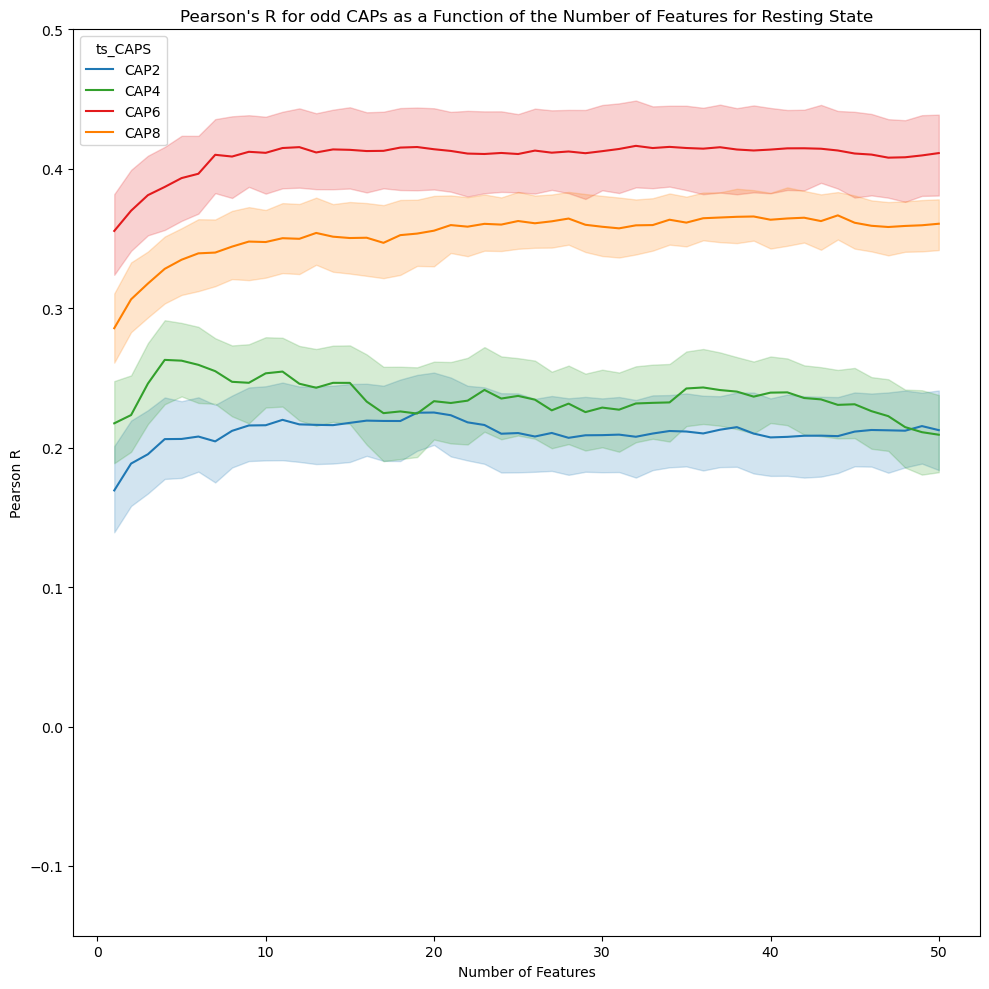

In [12]:
C = "even"
if C == "odd":
    caps = [f'CAP{c}'  for c in range(9) if c%2 != 0]
elif C == "even":
    caps = [f'CAP{c}'  for c in range(9) if c%2 == 0]

petit_pd = gros_pd.groupby(['subject','session','ts_CAPS','n_features']).mean('pearson_r').reset_index()
selected_caps = petit_pd[petit_pd['ts_CAPS'].isin(caps)]
figure = plt.figure(figsize=(10,10))
sns.lineplot(x="n_features", 
             y="pearson_r",
             hue="ts_CAPS",
             data=petit_pd,
             palette="Paired",
             errorbar=('ci', 68),
             #alpha = 1,
             hue_order=[c  if c in caps else '' for c in gros_pd['ts_CAPS'].unique()]
             )
if TASK == 'rest':
    t = "Resting State"
else:
    t = TASK.capitalize()
plt.title(f"Pearson's R for odd CAPs as a Function of the Number of Features for {t}")
plt.ylabel('Pearson R')
plt.xlabel('Number of Features')

plt.ylim(-0.15,0.5)
plt.tight_layout()
plt.savefig(f"/home/slouviot/01_projects/eeg_brain_state_prediction/figures/custom_bands_features_investigation/double_dipping/prediction_as_function_nb_features_subject_level_{C}_task-{TASK}_with_pupil.png")

In [5]:
gros_pd

,index,subject,session,ts_CAPS,pearson_r,frequency_Hz,electrode,n_features,task,description
0,0,1,1,CAP1,0.406108,[3],[60],1,rest,CustomEnvBk8Caps
1,1,1,1,CAP2,0.383903,[3],[60],1,rest,CustomEnvBk8Caps
2,2,1,1,CAP3,-0.058374,[8],[58],1,rest,CustomEnvBk8Caps
3,3,1,1,CAP4,0.059902,[8],[58],1,rest,CustomEnvBk8Caps
4,4,1,1,CAP5,0.154463,[14],[25],1,rest,CustomEnvBk8Caps
...,...,...,...,...,...,...,...,...,...,...
795,795,14,2,CAP4,-0.028833,[ 8 8 9 8 7 10 7 8 7 7 19 8 11 7 9 ...,[58 9 58 15 9 58 58 44 44 19 9 8 58 8 9 ...,50,rest,CustomEnvBk8Caps
796,796,14,2,CAP5,0.104895,[14 14 15 13 16 15 14 12 11 14 12 11 13 13 2 ...,[25 53 53 25 53 10 10 11 11 46 52 52 46 40 60 ...,50,rest,CustomEnvBk8Caps
797,797,14,2,CAP6,0.117807,[16 14 15 13 14 14 12 11 15 12 14 11 13 15 3 ...,[53 25 53 25 53 10 11 11 10 52 46 52 46 25 16 ...,50,rest,CustomEnvBk8Caps
798,798,14,2,CAP7,0.184179,[ 3 2 2 12 11 10 2 3 2 2 3 4 3 2 3 ...,[16 59 1 52 52 52 7 7 23 0 38 16 1 38 59 ...,50,rest,CustomEnvBk8Caps


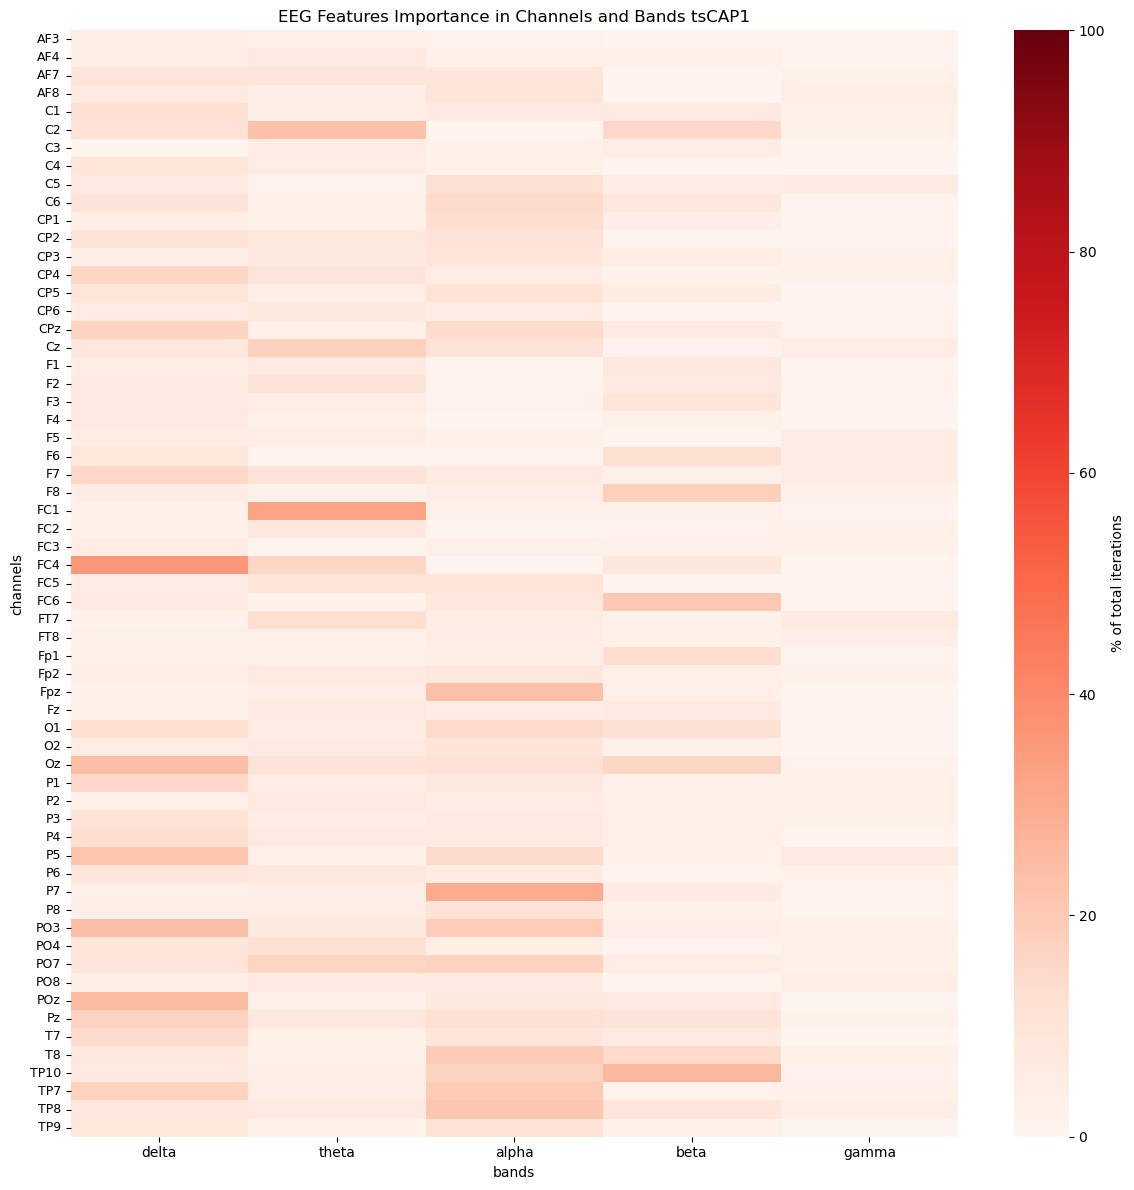

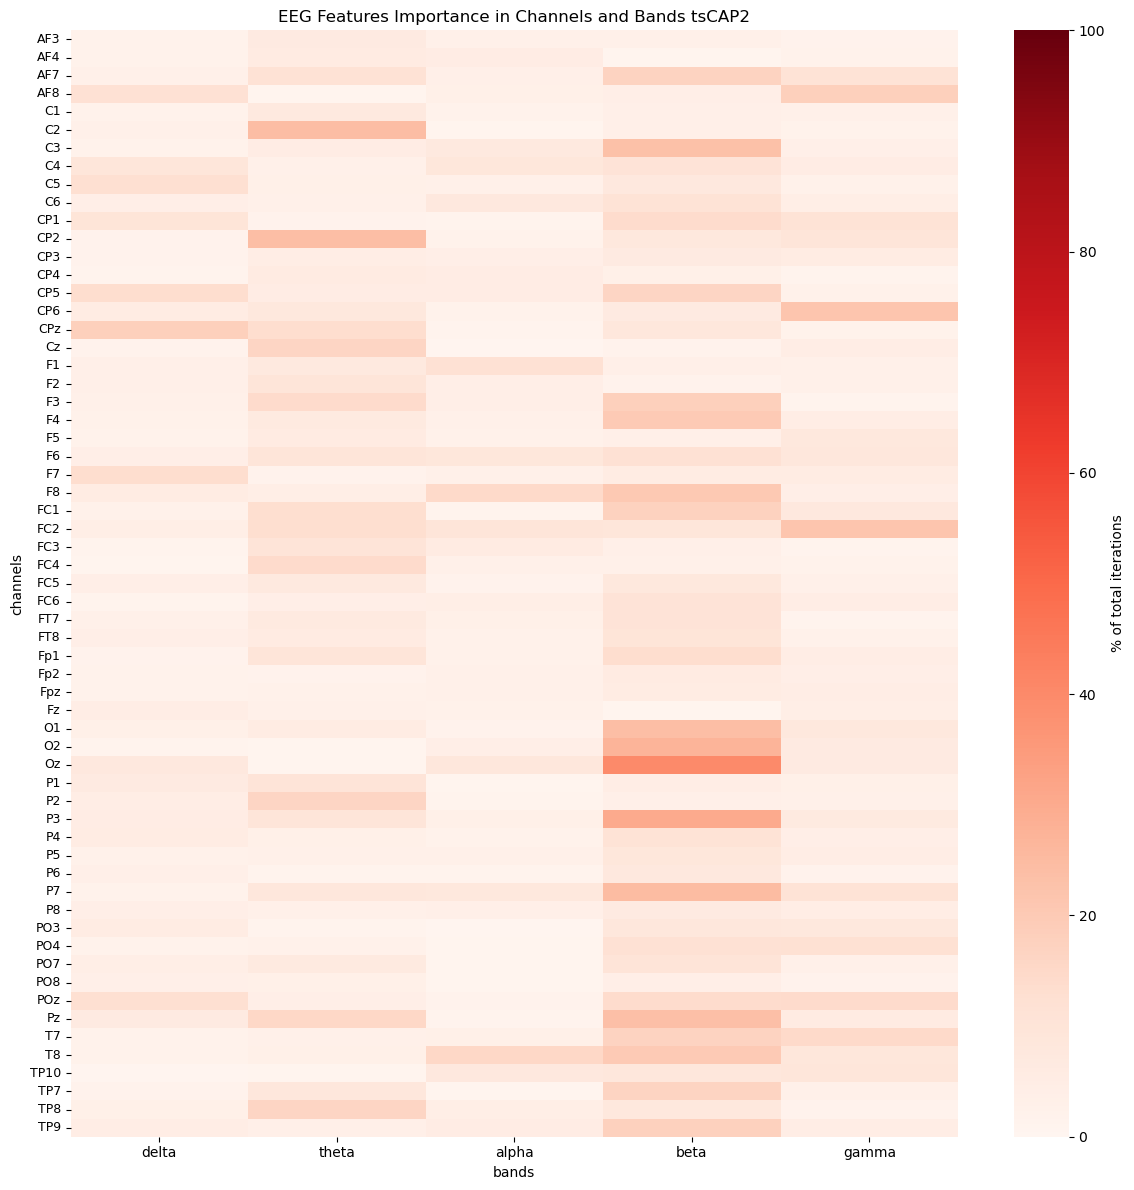

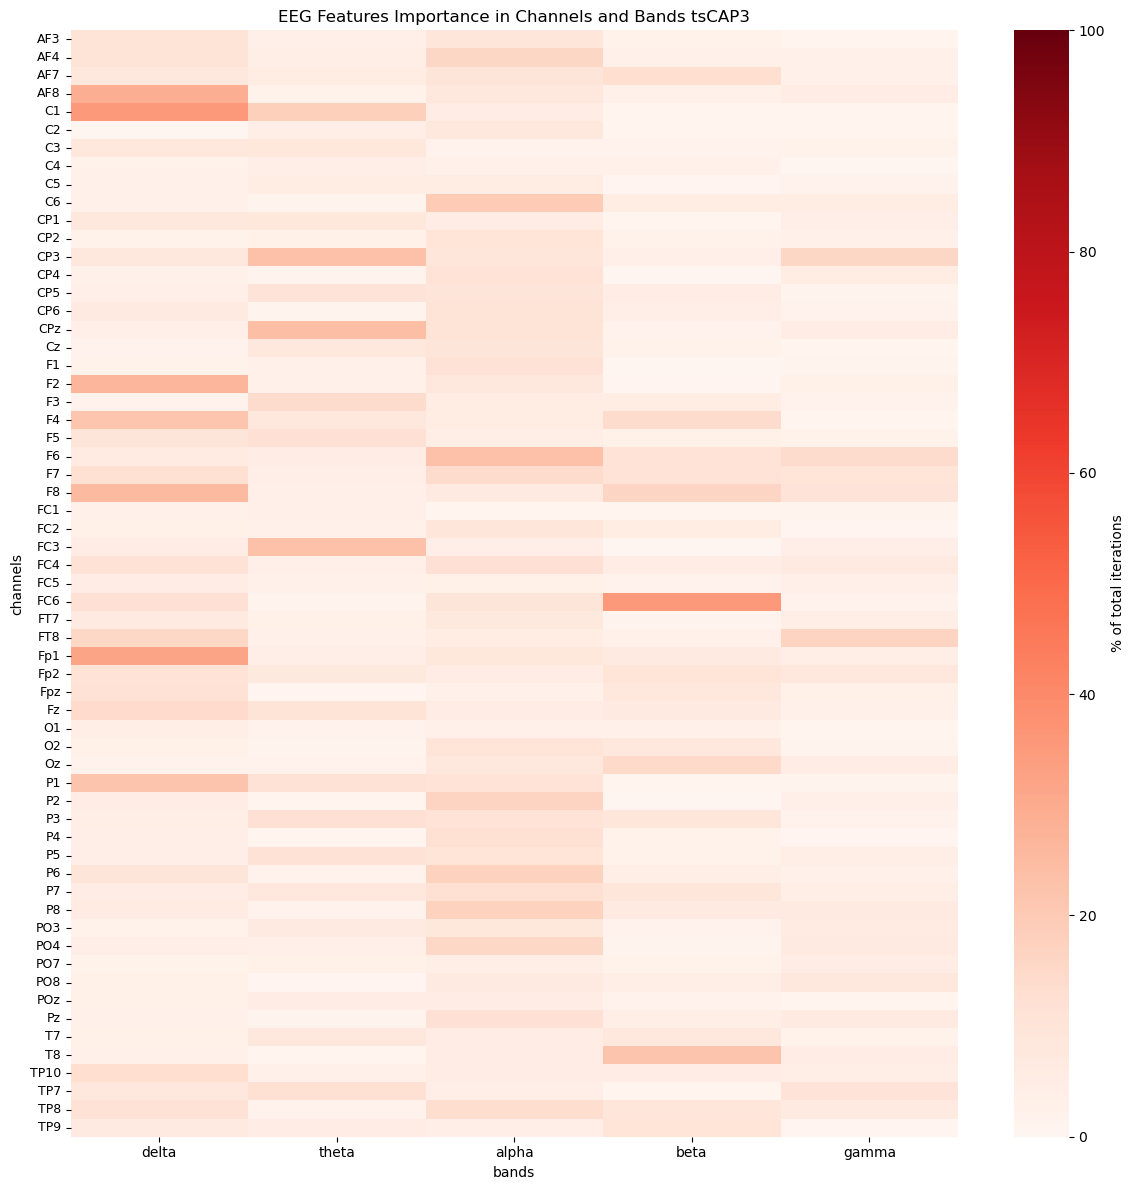

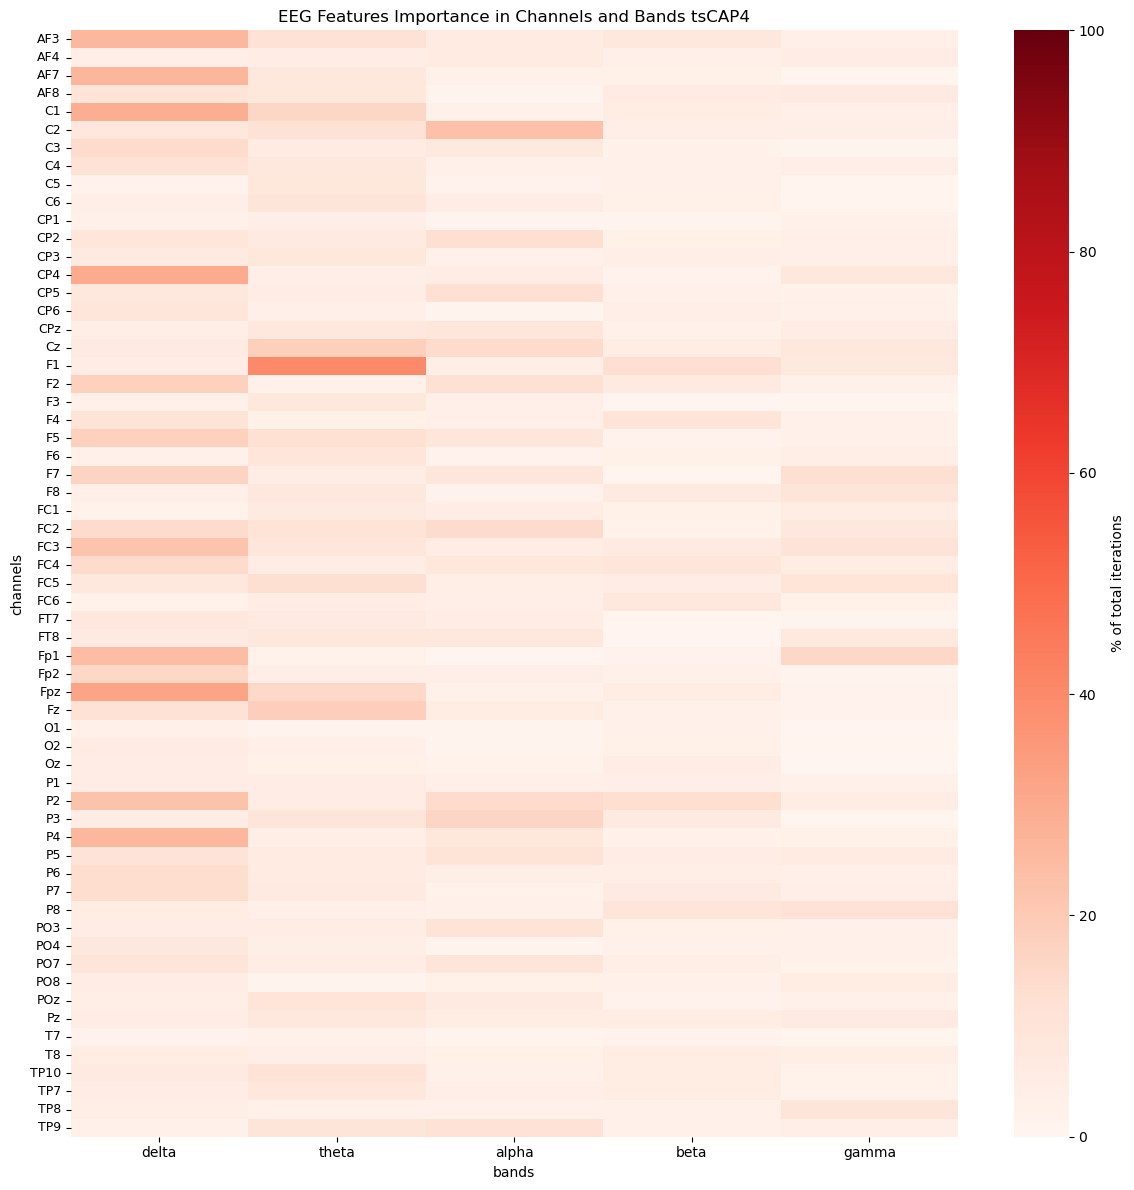

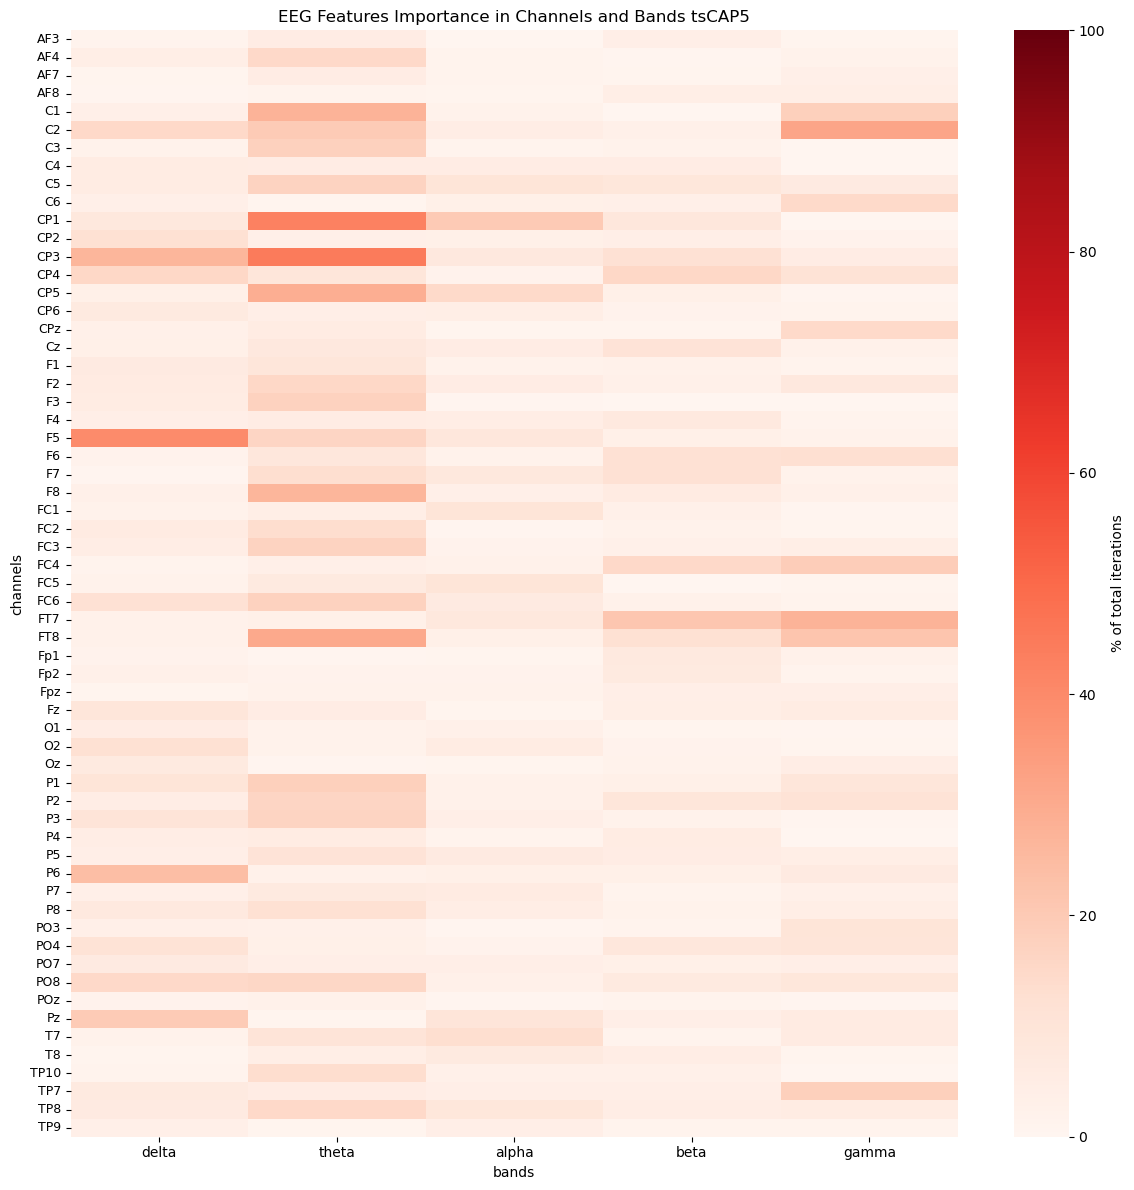

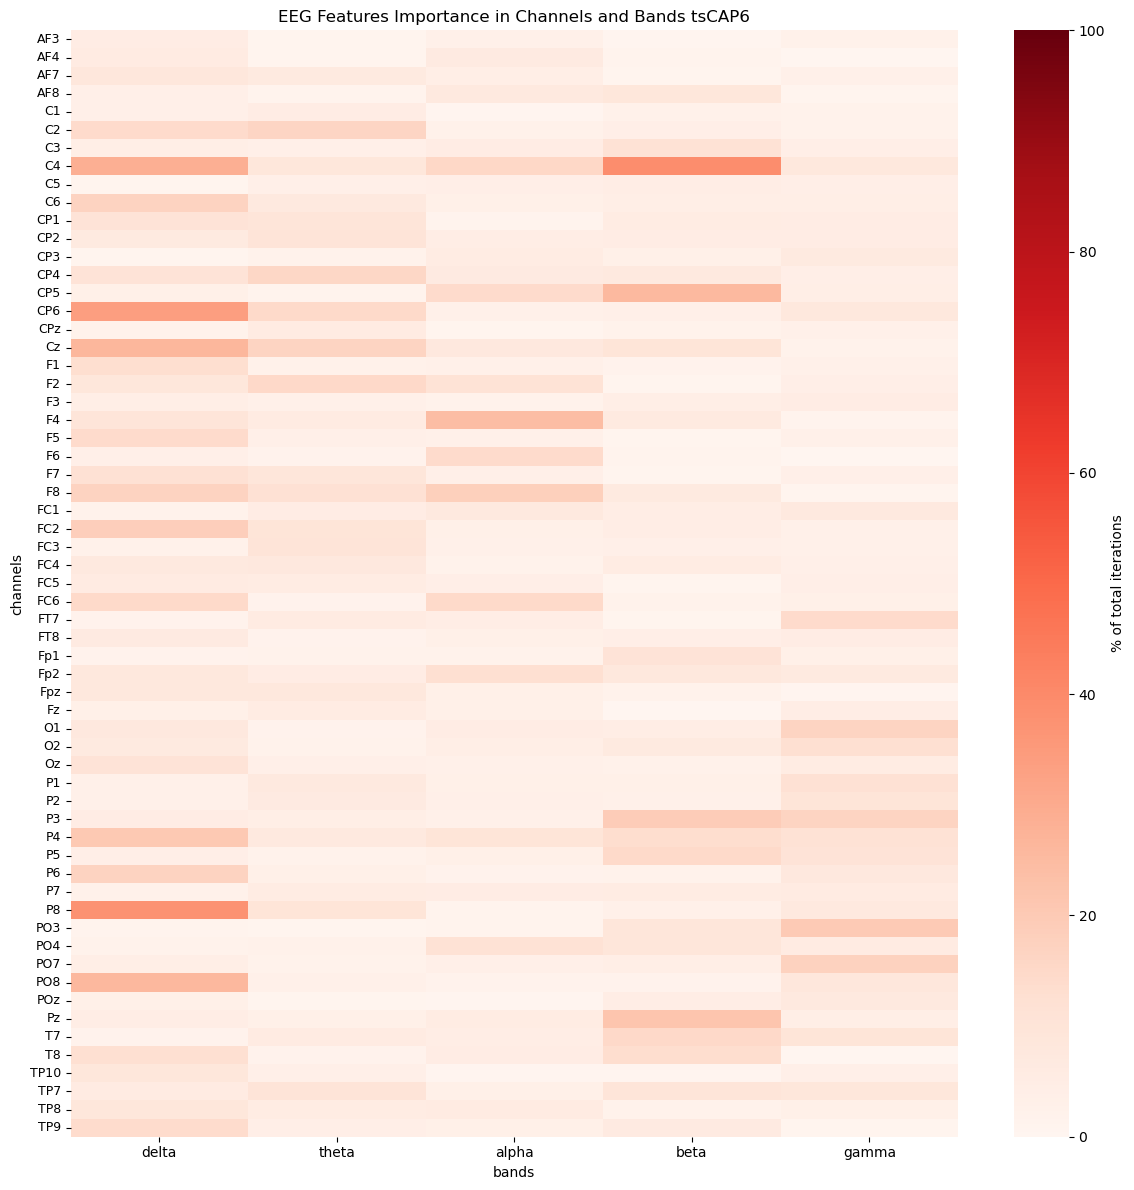

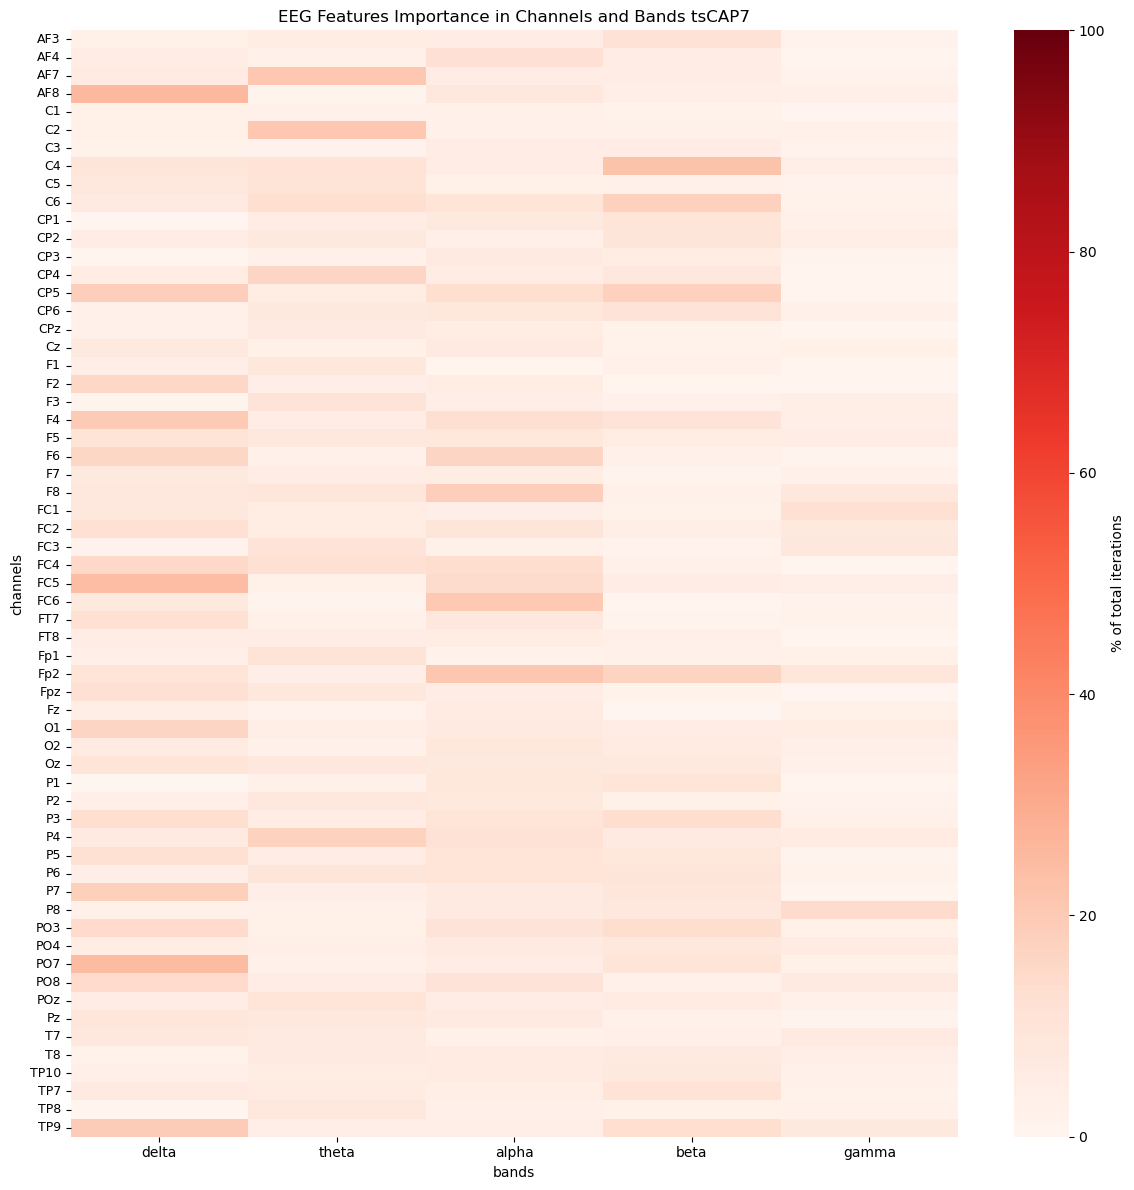

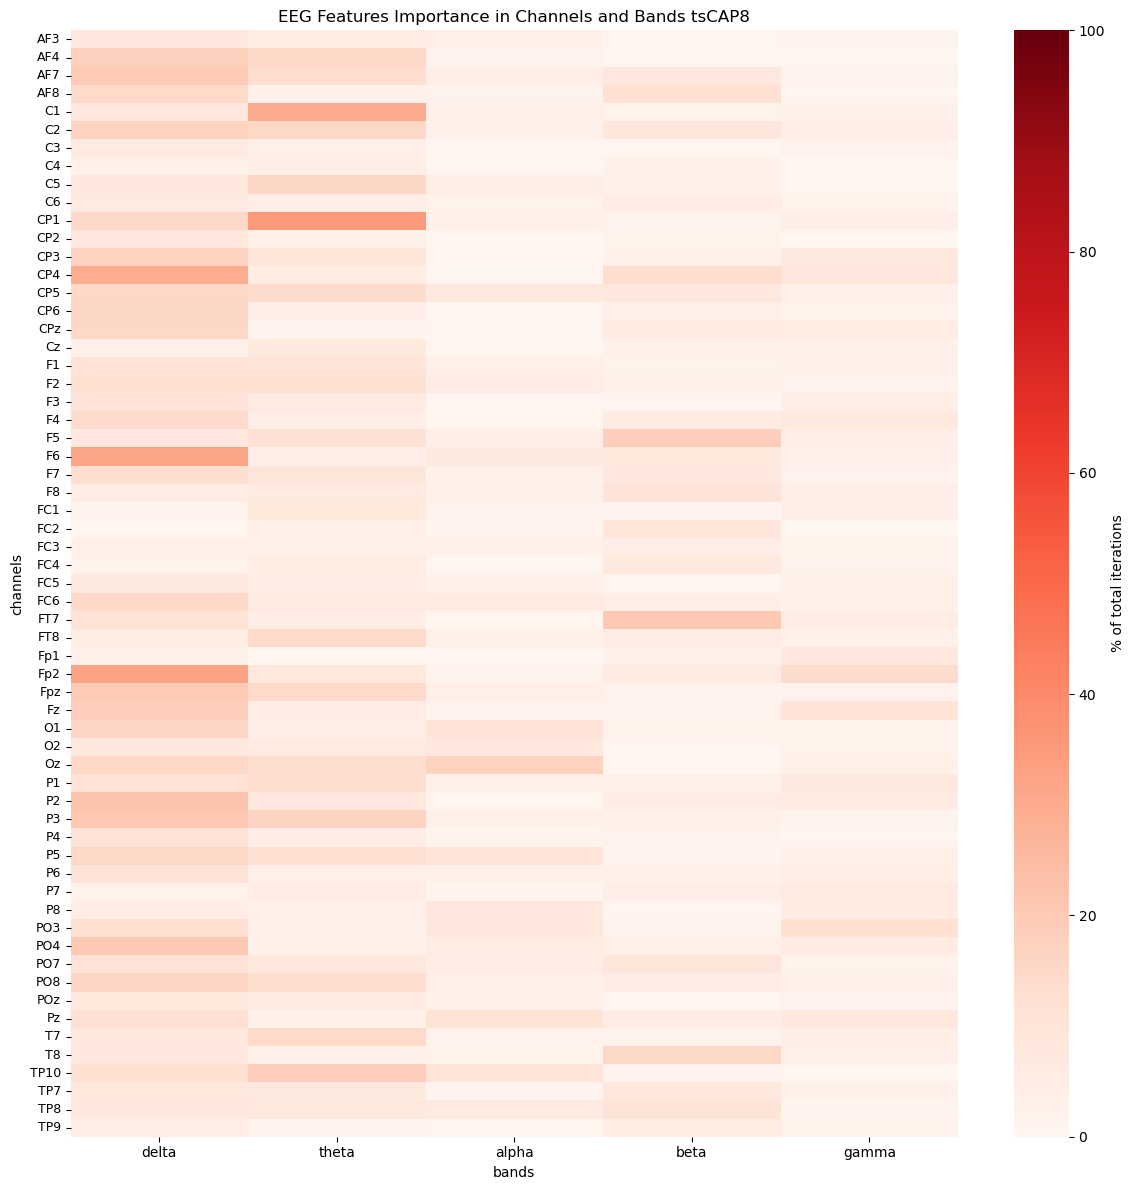

In [10]:
import numpy as np
for cap in gros_pd['ts_CAPS'].unique():
    petit_pd2 = gros_pd.loc[gros_pd['ts_CAPS'] == cap, ['eye_features','eeg_features_channel','eeg_features_band']]
    petit_pd2 = petit_pd2.dropna(axis = 0)
    all_channels = petit_pd2.eeg_features_channel.apply(lambda x: x[1:-1].replace("'","").replace(" ","").split(',') if x is not np.nan else [np.nan]).values
    all_bands = petit_pd2.eeg_features_band.apply(lambda x: x[1:-1].replace("'","").replace(" ","").split(',') if x is not np.nan else [np.nan]).values
    all_channels = np.concatenate(all_channels)
    all_bands = np.concatenate(all_bands)
    dict_for_df = {'channels':all_channels,
                'bands': all_bands}
    eeg_df = pd.DataFrame(dict_for_df)
    pivoted = eeg_df.groupby('bands').value_counts().to_frame().reset_index().pivot(
        columns = 'bands', 
        index = 'channels', 
        values = 'count',
                            ) * 100 / (64 * 28 * 10)
    figure = plt.figure(figsize=(12,12))
    sns.heatmap(pivoted.loc[:,['delta','theta','alpha','beta','gamma']],
                #xticklabels=['delta','theta','alpha','beta','gamma'],
                cmap = 'Reds',
                cbar_kws={'label':'% of total iterations',
                          },
                vmin = 0,
                vmax = 100
                )
    plt.yticks(fontsize = 9)
    plt.title(f'EEG Features Importance in Channels and Bands {cap}')
    plt.tight_layout()
    plt.savefig(f'../figures/eeg_features_importance_{cap}.png')

In [7]:
gros_pd

,index,iteration,subject,session,run,task,ts_CAPS,pearson_r,eye_features,eeg_features_channel,eeg_features_band,nb_features
0,0,1,sub-01,ses-01,run-01,task-checker,tsCAP1,0.622747,['pupil_dilation'],NaN,NaN,1
1,1,1,sub-01,ses-01,run-01,task-checker,tsCAP2,0.499358,['first_derivative'],NaN,NaN,1
2,2,1,sub-01,ses-01,run-01,task-checker,tsCAP3,0.227599,['first_derivative'],NaN,NaN,1
3,3,1,sub-01,ses-01,run-01,task-checker,tsCAP4,0.378649,['pupil_dilation'],NaN,NaN,1
4,4,1,sub-01,ses-01,run-01,task-checker,tsCAP5,0.303291,['first_derivative'],NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2155,2155,10,sub-22,ses-02,run-01,task-checker,tsCAP6,0.254941,"['pupil_dilation', 'second_derivative', 'first...","['CP5', 'F4', 'C3', 'PO4', 'CP5', 'C3', 'POz',...","['alpha', 'alpha', 'alpha', 'alpha', 'gamma', ...",28
2156,2156,10,sub-22,ses-01,run-01,task-checker,tsCAP7,-0.004938,"['pupil_dilation', 'first_derivative', 'second...","['P3', 'CP1', 'CP2', 'Cz', 'P8', 'C4', 'P4', '...","['beta', 'gamma', 'gamma', 'beta', 'gamma', 'g...",28
2157,2157,10,sub-22,ses-02,run-01,task-checker,tsCAP7,0.167144,"['pupil_dilation', 'first_derivative', 'second...","['P3', 'CP1', 'CP2', 'Cz', 'P8', 'C4', 'P4', '...","['beta', 'gamma', 'gamma', 'beta', 'gamma', 'g...",28
2158,2158,10,sub-22,ses-01,run-01,task-checker,tsCAP8,-0.126097,"['pupil_dilation', 'first_derivative', 'second...","['Fp1', 'F4', 'F3', 'C3', 'FC6', 'F5', 'P7', '...","['gamma', 'gamma', 'gamma', 'gamma', 'gamma', ...",28


In [6]:
1000*100/(64 * 10 * 27) 

5.787037037037037

In [4]:
gros_pd[gros_pd['ts_CAPS'] == 'tsCAP1'].groupby(['subject','session']).mean('pearson_r').reset_index()

,subject,session,index,iteration,pearson_r,nb_features
0,sub-01,ses-01,0.000,10.0,0.464166,32.5
1,sub-02,ses-01,8.000,10.0,0.312473,32.5
2,sub-03,ses-01,16.000,10.0,0.963188,2.0
3,sub-05,ses-02,16.375,10.0,0.068786,32.5
4,sub-06,ses-01,24.375,10.0,0.188104,32.5
5,sub-06,ses-02,25.375,10.0,0.195728,32.5
6,sub-07,ses-01,40.375,10.0,0.205171,32.5
7,sub-07,ses-02,41.375,10.0,0.317275,32.5
8,sub-08,ses-01,56.375,10.0,-0.059265,32.5
9,sub-08,ses-02,57.375,10.0,0.247444,32.5


In [9]:
all_eyes = petit_pd2.eye_features.apply(lambda x: x[1:-1].replace("'","").replace(" ","").split(',')).values()

In [13]:
all_eyes = np.concatenate(all_eyes)
df_all_eyes = pd.DataFrame({'eye_features':all_eyes})


In [15]:
df_all_eyes.value_counts().reset_index().pivot(columns = 'eye_features')

count                                 
eye_features first_derivative pupil_dilation second_derivative
0                      5032.0            NaN               NaN
1                         NaN         5032.0               NaN
2                         NaN            NaN            5032.0

,eye_features
0,pupil_dilation
1,first_derivative
2,second_derivative
3,pupil_dilation
4,first_derivative
...,...
15091,second_derivative
15092,first_derivative
15093,pupil_dilation
15094,second_derivative
